# Computer Vision Lab 03 — Edge Detection Techniques and Their Impact on Classification Performance

This notebook follows the dataset setup used in Lab 01 and Lab 02.

**Dataset:** ISIC skin-lesion dataset retrieved directly in code with `kagglehub`  
**Selected classes:** the same fixed 5 classes used in Labs 01–02  
**Input size:** 224 × 224  
**Train/Validation/Test:** the same stratified 90/10 split of the official Train folder, with the official Test folder kept separate.

Lab 03 requirements covered:
- Sobel Gx, Sobel Gy and gradient magnitude
- Prewitt
- Laplacian
- Laplacian of Gaussian (LoG)
- Canny
- Gaussian and Salt-and-Pepper noise
- Gaussian and Median filtering
- Canny threshold/kernel analysis
- Raw vs filtered vs edge-image classification
- Accuracy, Precision, Recall, F1-score, training time and inference time
- Confusion matrices and comparison graphs
- Table 1, Table 2 and Table 3

In [1]:
# 1. SETUP
!pip install -q kagglehub opencv-python-headless scikit-learn

import os
import time
import copy
import random
import warnings

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# Same settings as Labs 01–02
IMG_SIZE = 224
BATCH_SIZE = 32

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# IMPORTANT: replace this with the actual best preprocessing method from Lab 02.
LAB2_BEST_FILTER = "Gaussian"

# Edge configuration selected after Task 3.
# This is initialized to the commonly useful middle threshold pair,
# but Task 3 below measures all required configurations first.
BEST_CANNY_LOW = 50
BEST_CANNY_HIGH = 150
BEST_CANNY_KERNEL = 3

SELECTED_CLASSES = [
    "actinic keratosis",
    "basal cell carcinoma",
    "melanoma",
    "nevus",
    "pigmented benign keratosis",
]

CLASS_TO_IDX = {c: i for i, c in enumerate(SELECTED_CLASSES)}
NUM_CLASSES = len(SELECTED_CLASSES)

print("Selected classes:")
for i, c in enumerate(SELECTED_CLASSES):
    print(f"{i}: {c}")

Device: cuda
Selected classes:
0: actinic keratosis
1: basal cell carcinoma
2: melanoma
3: nevus
4: pigmented benign keratosis


## 2. Load the same dataset directly through code

In [2]:
import kagglehub

# Dataset is retrieved directly through Python; no manual file download is required.
path = kagglehub.dataset_download("nodoubttome/skin-cancer9-classesisic")
print("Dataset path:", path)

BASE_DIR = os.path.join(
    path,
    "Skin cancer ISIC The International Skin Imaging Collaboration"
)
TRAIN_DIR = os.path.join(BASE_DIR, "Train")
TEST_DIR  = os.path.join(BASE_DIR, "Test")

assert os.path.isdir(TRAIN_DIR), f"Train directory not found: {TRAIN_DIR}"
assert os.path.isdir(TEST_DIR), f"Test directory not found: {TEST_DIR}"

ALL_CLASS_NAMES = sorted(os.listdir(TRAIN_DIR))
print(f"All classes available ({len(ALL_CLASS_NAMES)}):")
print(ALL_CLASS_NAMES)

Using Colab cache for faster access to the 'skin-cancer9-classesisic' dataset.
Dataset path: /kaggle/input/skin-cancer9-classesisic
All classes available (9):
['actinic keratosis', 'basal cell carcinoma', 'dermatofibroma', 'melanoma', 'nevus', 'pigmented benign keratosis', 'seborrheic keratosis', 'squamous cell carcinoma', 'vascular lesion']


,Number of training images
actinic keratosis,114
basal cell carcinoma,376
melanoma,438
nevus,357
pigmented benign keratosis,462


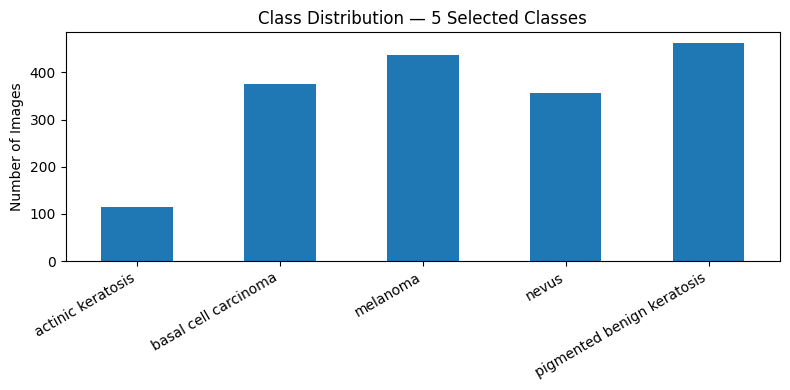

In [3]:
def filter_imagefolder_to_classes(dataset, class_to_idx):
    old_idx_to_class = {v: k for k, v in dataset.class_to_idx.items()}

    new_samples = [
        (p, class_to_idx[old_idx_to_class[label]])
        for p, label in dataset.samples
        if old_idx_to_class[label] in class_to_idx
    ]

    dataset.samples = new_samples
    dataset.imgs = new_samples
    dataset.targets = [s[1] for s in new_samples]
    dataset.classes = list(class_to_idx.keys())
    dataset.class_to_idx = class_to_idx
    return dataset


missing = [c for c in SELECTED_CLASSES if c not in ALL_CLASS_NAMES]
assert not missing, f"Missing selected classes: {missing}"

# Inspect class distribution
raw_train = filter_imagefolder_to_classes(
    datasets.ImageFolder(TRAIN_DIR),
    CLASS_TO_IDX
)

counts = pd.Series(
    [SELECTED_CLASSES[t] for t in raw_train.targets]
).value_counts().reindex(SELECTED_CLASSES)

display(counts.to_frame("Number of training images"))

plt.figure(figsize=(8, 4))
counts.plot(kind="bar")
plt.title("Class Distribution — 5 Selected Classes")
plt.ylabel("Number of Images")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 3. Fixed train/validation/test split

In [4]:
# Exactly the same split principle as Labs 01–02:
# 90% of the official Train folder -> train
# 10% of the official Train folder -> validation
# official Test folder -> final test

_base_ds = filter_imagefolder_to_classes(
    datasets.ImageFolder(TRAIN_DIR),
    CLASS_TO_IDX
)

targets = np.array(_base_ds.targets)
indices = np.arange(len(targets))

TRAIN_IDX, VAL_IDX = train_test_split(
    indices,
    test_size=0.10,
    stratify=targets,
    random_state=SEED
)

print("Train images:", len(TRAIN_IDX))
print("Validation images:", len(VAL_IDX))
print("Official test images:", len(
    filter_imagefolder_to_classes(
        datasets.ImageFolder(TEST_DIR),
        CLASS_TO_IDX
    )
))

Train images: 1572
Validation images: 175
Official test images: 80


## 4. Edge-detection functions

In [5]:
def to_gray(img_rgb):
    return cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)


def normalize_edge(edge):
    edge = np.abs(edge).astype(np.float32)
    edge = cv2.normalize(edge, None, 0, 255, cv2.NORM_MINMAX)
    return edge.astype(np.uint8)


def sobel_gx(img_rgb):
    gray = to_gray(img_rgb)
    gx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    return normalize_edge(gx)


def sobel_gy(img_rgb):
    gray = to_gray(img_rgb)
    gy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    return normalize_edge(gy)


def sobel_magnitude(img_rgb):
    gray = to_gray(img_rgb)
    gx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    mag = cv2.magnitude(gx.astype(np.float32), gy.astype(np.float32))
    return normalize_edge(mag)


def prewitt(img_rgb):
    gray = to_gray(img_rgb).astype(np.float32)

    kernel_x = np.array([
        [-1, 0, 1],
        [-1, 0, 1],
        [-1, 0, 1]
    ], dtype=np.float32)

    kernel_y = np.array([
        [-1, -1, -1],
        [ 0,  0,  0],
        [ 1,  1,  1]
    ], dtype=np.float32)

    px = cv2.filter2D(gray, -1, kernel_x)
    py = cv2.filter2D(gray, -1, kernel_y)

    mag = cv2.magnitude(px, py)
    return normalize_edge(mag)


def laplacian(img_rgb):
    gray = to_gray(img_rgb)
    lap = cv2.Laplacian(gray, cv2.CV_64F, ksize=3)
    return normalize_edge(lap)


def log_edge(img_rgb, kernel_size=5, sigma=1.0):
    gray = to_gray(img_rgb)
    blurred = cv2.GaussianBlur(gray, (kernel_size, kernel_size), sigmaX=sigma)
    log = cv2.Laplacian(blurred, cv2.CV_64F, ksize=3)
    return normalize_edge(log)


def canny(img_rgb, low=50, high=150, kernel_size=3):
    gray = to_gray(img_rgb)
    if kernel_size > 3:
        gray = cv2.GaussianBlur(gray, (kernel_size, kernel_size), 0)
    return cv2.Canny(gray, low, high)


EDGE_METHODS = {
    "Sobel Gx": sobel_gx,
    "Sobel Gy": sobel_gy,
    "Sobel Magnitude": sobel_magnitude,
    "Prewitt": prewitt,
    "Laplacian": laplacian,
    "LoG": log_edge,
    "Canny": lambda img: canny(
        img,
        BEST_CANNY_LOW,
        BEST_CANNY_HIGH,
        BEST_CANNY_KERNEL
    ),
}

print("Edge detectors:", list(EDGE_METHODS.keys()))

Edge detectors: ['Sobel Gx', 'Sobel Gy', 'Sobel Magnitude', 'Prewitt', 'Laplacian', 'LoG', 'Canny']


## 5. Task 1 — Comparative Edge Detection
Required comparison: **Original → Sobel → Prewitt → Laplacian → LoG → Canny**

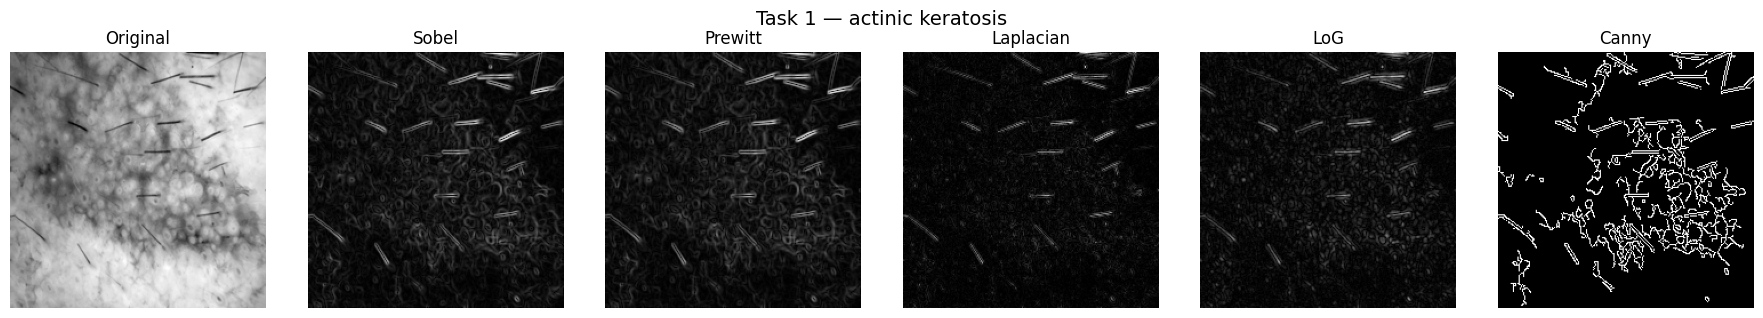

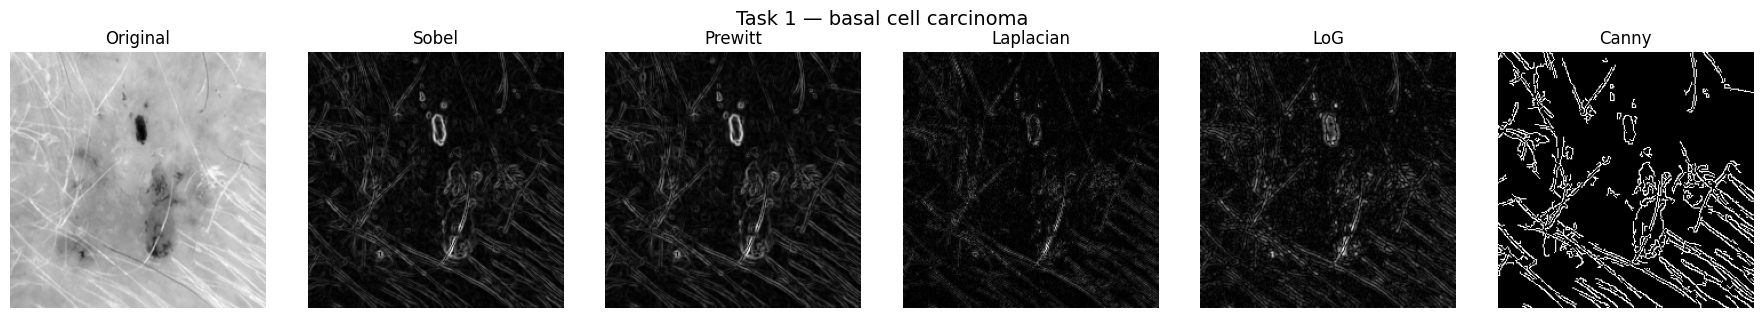

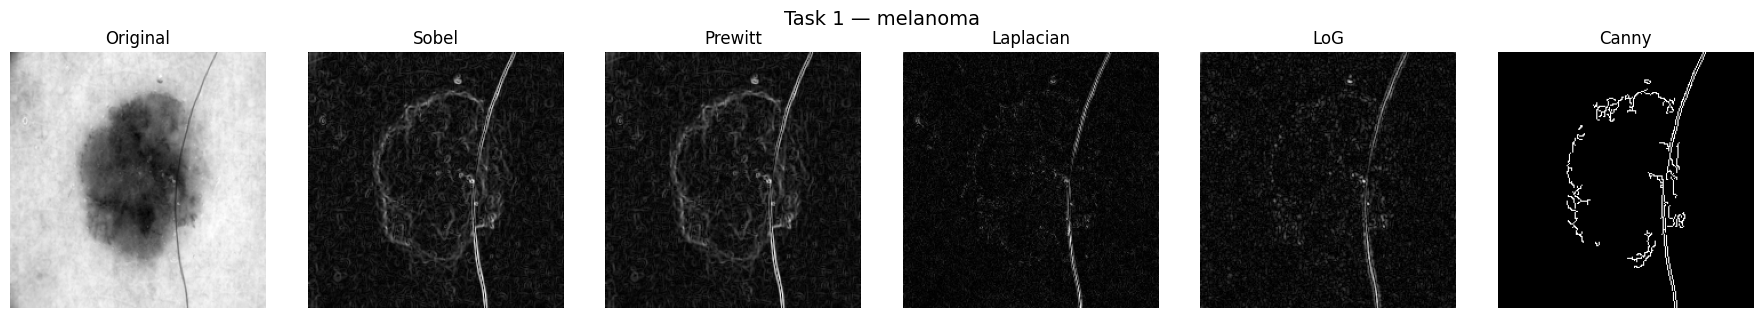

In [6]:
# Pick one representative image from each of three different classes.
representative_paths = []

for class_name in SELECTED_CLASSES[:3]:
    class_idx = CLASS_TO_IDX[class_name]
    class_samples = [p for p, y in raw_train.samples if y == class_idx]
    representative_paths.append((class_name, class_samples[0]))

def load_rgb(path):
    return np.array(
        Image.open(path).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
    )

for class_name, img_path in representative_paths:
    img = load_rgb(img_path)

    results = {
        "Original": to_gray(img),
        "Sobel": sobel_magnitude(img),
        "Prewitt": prewitt(img),
        "Laplacian": laplacian(img),
        "LoG": log_edge(img),
        "Canny": canny(img, BEST_CANNY_LOW, BEST_CANNY_HIGH, BEST_CANNY_KERNEL),
    }

    fig, axes = plt.subplots(1, 6, figsize=(18, 3.2))
    for ax, (title, result) in zip(axes, results.items()):
        ax.imshow(result, cmap="gray")
        ax.set_title(title)
        ax.axis("off")

    fig.suptitle(f"Task 1 — {class_name}", fontsize=14)
    plt.tight_layout()
    plt.show()

## 6. Task 2 — Noise generation and filtering

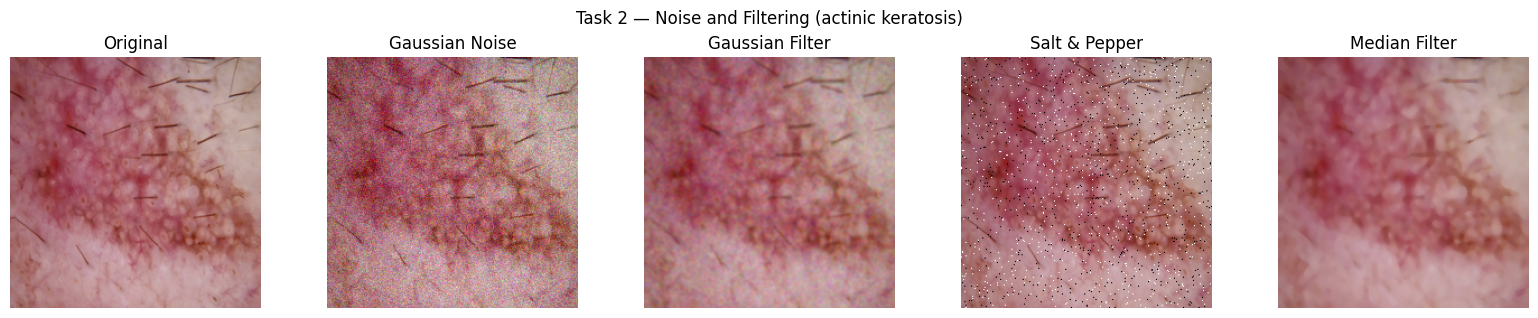

In [7]:
def add_gaussian_noise(img_rgb, mean=0, sigma=20):
    img = img_rgb.astype(np.float32)
    noise = np.random.normal(mean, sigma, img.shape)
    noisy = np.clip(img + noise, 0, 255)
    return noisy.astype(np.uint8)


def add_salt_pepper_noise(img_rgb, amount=0.03, salt_vs_pepper=0.5):
    noisy = img_rgb.copy()
    h, w, _ = noisy.shape

    num_pixels = int(amount * h * w)
    num_salt = int(num_pixels * salt_vs_pepper)
    num_pepper = num_pixels - num_salt

    ys = np.random.randint(0, h, num_salt)
    xs = np.random.randint(0, w, num_salt)
    noisy[ys, xs] = 255

    ys = np.random.randint(0, h, num_pepper)
    xs = np.random.randint(0, w, num_pepper)
    noisy[ys, xs] = 0

    return noisy


def gaussian_filter(img_rgb, kernel_size=5):
    return cv2.GaussianBlur(img_rgb, (kernel_size, kernel_size), 0)


def median_filter(img_rgb, kernel_size=5):
    return cv2.medianBlur(img_rgb, kernel_size)


sample_class, sample_path = representative_paths[0]
sample = load_rgb(sample_path)

gaussian_noisy = add_gaussian_noise(sample)
sp_noisy = add_salt_pepper_noise(sample)

fig, axes = plt.subplots(1, 5, figsize=(16, 3.2))
images = [
    ("Original", sample),
    ("Gaussian Noise", gaussian_noisy),
    ("Gaussian Filter", gaussian_filter(gaussian_noisy)),
    ("Salt & Pepper", sp_noisy),
    ("Median Filter", median_filter(sp_noisy)),
]

for ax, (title, im) in zip(axes, images):
    ax.imshow(im)
    ax.set_title(title)
    ax.axis("off")

plt.suptitle(f"Task 2 — Noise and Filtering ({sample_class})")
plt.tight_layout()
plt.show()

### Task 2 edge-map comparison

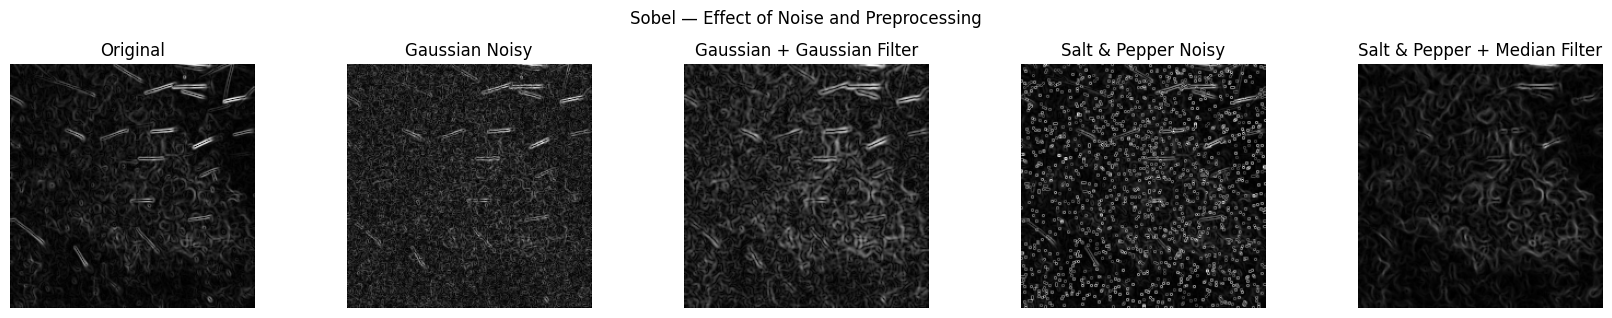

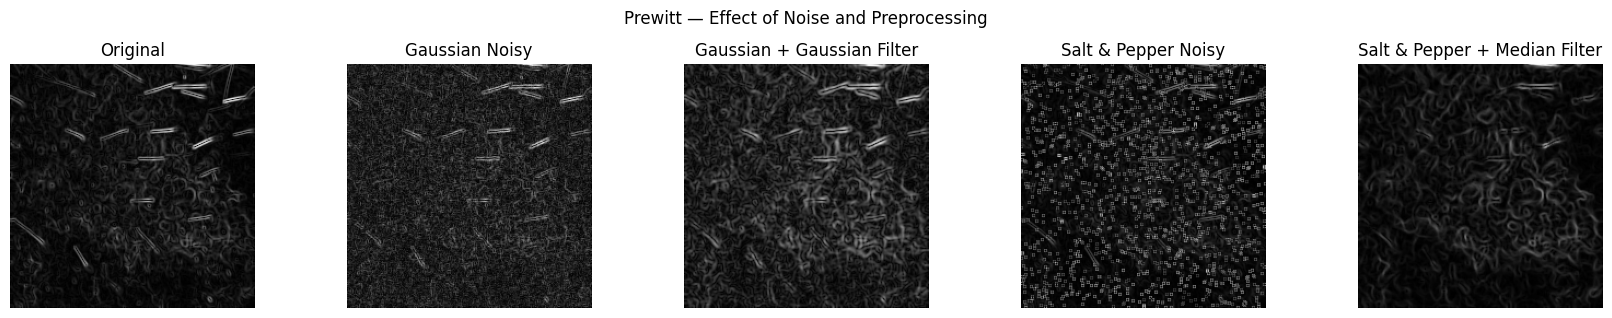

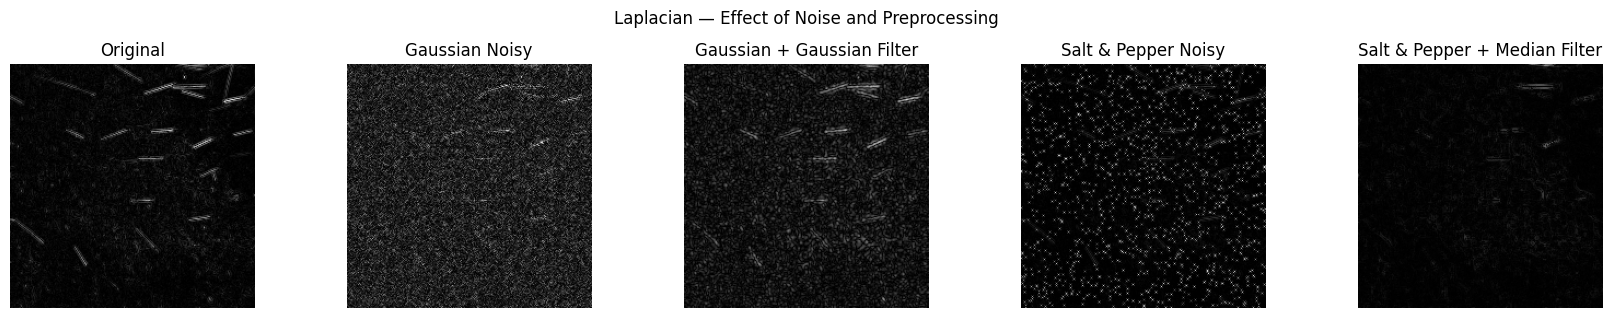

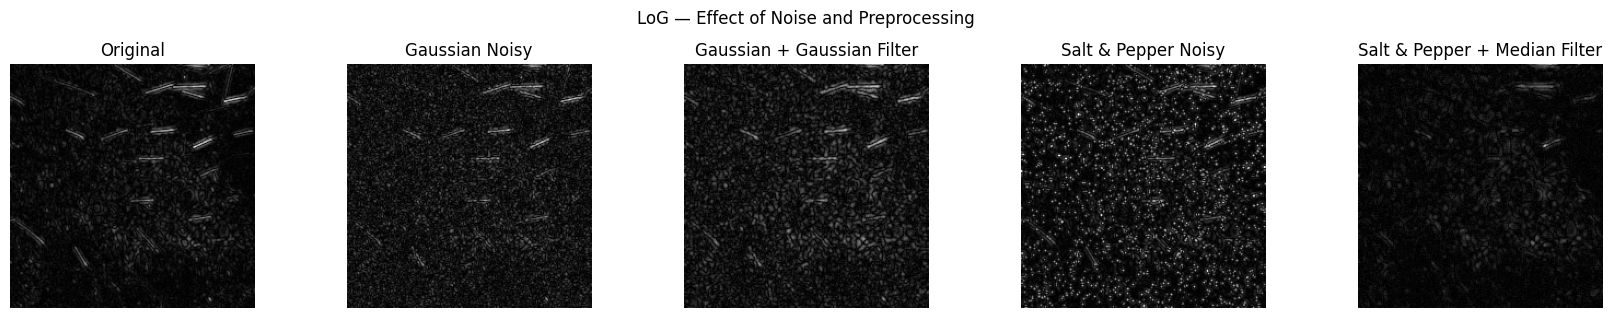

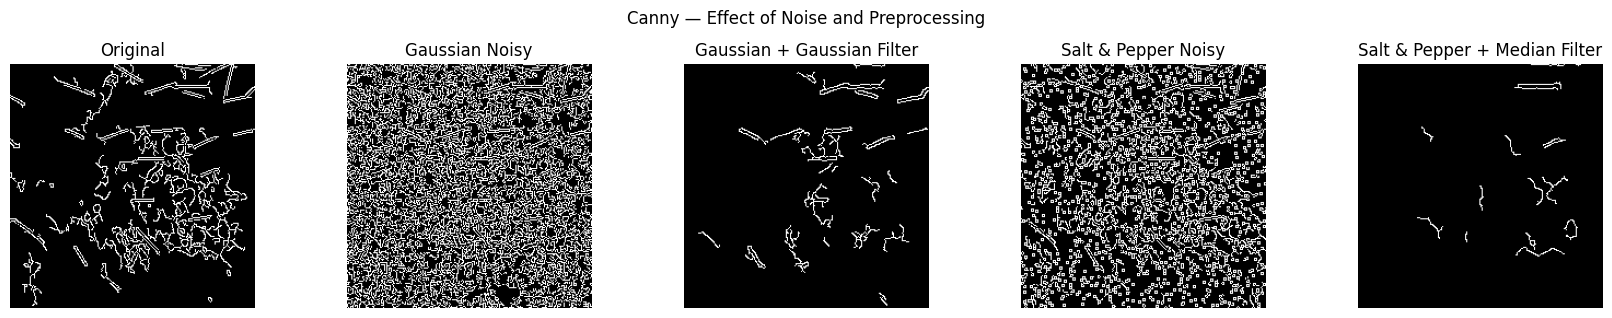

In [8]:
noise_cases = [
    ("Original", sample),
    ("Gaussian Noisy", gaussian_noisy),
    ("Gaussian + Gaussian Filter", gaussian_filter(gaussian_noisy)),
    ("Salt & Pepper Noisy", sp_noisy),
    ("Salt & Pepper + Median Filter", median_filter(sp_noisy)),
]

for method_name, method in [
    ("Sobel", sobel_magnitude),
    ("Prewitt", prewitt),
    ("Laplacian", laplacian),
    ("LoG", log_edge),
    ("Canny", lambda x: canny(x, BEST_CANNY_LOW, BEST_CANNY_HIGH, BEST_CANNY_KERNEL))
]:
    fig, axes = plt.subplots(1, 5, figsize=(17, 3.2))

    for ax, (title, im) in zip(axes, noise_cases):
        ax.imshow(method(im), cmap="gray")
        ax.set_title(title)
        ax.axis("off")

    fig.suptitle(f"{method_name} — Effect of Noise and Preprocessing")
    plt.tight_layout()
    plt.show()

### Table 1 — Effect of Noise and Preprocessing
The code below generates a structured table. The qualitative fields are intentionally left for experimental observation rather than fabricated automatically.

In [9]:
table1 = pd.DataFrame([
    ["Sobel", "Original", "None", "None", "", "", ""],
    ["Sobel", "Noisy", "Gaussian", "None", "", "", ""],
    ["Sobel", "Noisy", "Salt & Pepper", "None", "", "", ""],
    ["Sobel", "Noisy", "Gaussian", "Gaussian Filter", "", "", ""],
    ["Sobel", "Noisy", "Salt & Pepper", "Median Filter", "", "", ""],
    ["Prewitt", "Original", "None", "None", "", "", ""],
    ["Laplacian", "Original", "None", "None", "", "", ""],
    ["LoG", "Noisy", "Gaussian", "Gaussian Filter", "", "", ""],
    ["Canny", "Original", "None", "Built-in smoothing", "", "", ""],
    ["Canny", "Noisy", "Gaussian", "Gaussian Filter", "", "", ""],
    ["Canny", "Noisy", "Salt & Pepper", "Median Filter", "", "", ""],
], columns=[
    "Edge Detector", "Input Image", "Noise Type", "Preprocessing",
    "Edge Quality", "Noise Sensitivity", "Observations"
])

display(table1)

,Edge Detector,Input Image,Noise Type,Preprocessing,Edge Quality,Noise Sensitivity,Observations
0,Sobel,Original,None,None,,,
1,Sobel,Noisy,Gaussian,None,,,
2,Sobel,Noisy,Salt & Pepper,None,,,
3,Sobel,Noisy,Gaussian,Gaussian Filter,,,
4,Sobel,Noisy,Salt & Pepper,Median Filter,,,
5,Prewitt,Original,None,None,,,
6,Laplacian,Original,None,None,,,
7,LoG,Noisy,Gaussian,Gaussian Filter,,,
8,Canny,Original,None,Built-in smoothing,,,
9,Canny,Noisy,Gaussian,Gaussian Filter,,,


## 7. Task 3 — Canny Parameter Analysis

,Configuration,Low Threshold,High Threshold,Kernel Size,Edge Quality,Number of Detected Edges,Observation
0,Canny-1,30,100,3x3,,9416,
1,Canny-2,50,150,3x3,,4399,
2,Canny-3,100,200,3x3,,1441,
3,Canny-4,50,150,5x5,,961,


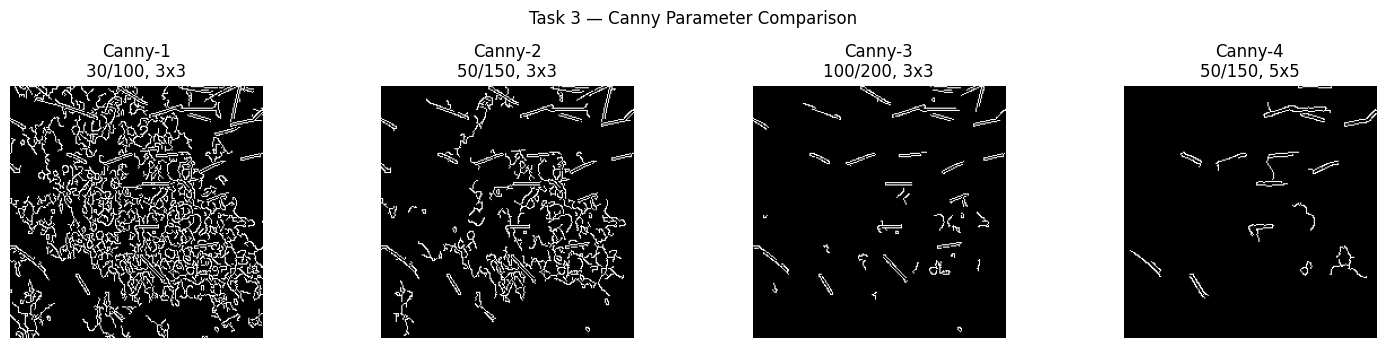

,Configuration,Number of Detected Edges
0,Canny-1,9416
1,Canny-2,4399
2,Canny-3,1441
3,Canny-4,961


In [10]:
# Required threshold combinations + a 5x5 kernel experiment.
canny_configs = [
    ("Canny-1", 30, 100, 3),
    ("Canny-2", 50, 150, 3),
    ("Canny-3", 100, 200, 3),
    ("Canny-4", 50, 150, 5),
]

canny_rows = []

for name, low, high, kernel in canny_configs:
    edge = canny(sample, low, high, kernel)

    # Number of detected edge pixels is an objective count.
    edge_pixels = int(np.count_nonzero(edge))

    canny_rows.append({
        "Configuration": name,
        "Low Threshold": low,
        "High Threshold": high,
        "Kernel Size": f"{kernel}x{kernel}",
        "Edge Quality": "",
        "Number of Detected Edges": edge_pixels,
        "Observation": ""
    })

canny_df = pd.DataFrame(canny_rows)
display(canny_df)

fig, axes = plt.subplots(1, 4, figsize=(15, 3.5))
for ax, (name, low, high, kernel) in zip(axes, canny_configs):
    edge = canny(sample, low, high, kernel)
    ax.imshow(edge, cmap="gray")
    ax.set_title(f"{name}\n{low}/{high}, {kernel}x{kernel}")
    ax.axis("off")

plt.suptitle("Task 3 — Canny Parameter Comparison")
plt.tight_layout()
plt.show()

# Objective reference only: this does NOT replace visual judgment.
canny_counts = canny_df[["Configuration", "Number of Detected Edges"]]
display(canny_counts)

### Selecting the best Canny configuration

Use the visual results and the edge-pixel counts above to decide which configuration is most useful for this dataset.

Then update the three variables in the setup cell:

```python
BEST_CANNY_LOW = ...
BEST_CANNY_HIGH = ...
BEST_CANNY_KERNEL = ...
```

The classification experiment below uses those values.

In [11]:
# For a fresh run, the default required middle configuration is used.
# CHANGE these values after visually selecting your best Task-3 result.
BEST_CANNY_LOW = 50
BEST_CANNY_HIGH = 150
BEST_CANNY_KERNEL = 3

print(
    "Selected Canny:",
    BEST_CANNY_LOW,
    BEST_CANNY_HIGH,
    f"{BEST_CANNY_KERNEL}x{BEST_CANNY_KERNEL}"
)

Selected Canny: 50 150 3x3


## 8. Dataset transforms for Raw, Lab-02 Filtered and Lab-03 Edge representations

In [12]:
def apply_lab2_filter(img_rgb, filter_name):
    if filter_name == "No Filter":
        return img_rgb
    if filter_name == "Average":
        return cv2.blur(img_rgb, (5, 5))
    if filter_name == "Gaussian":
        return cv2.GaussianBlur(img_rgb, (5, 5), sigmaX=0)
    if filter_name == "Median":
        return cv2.medianBlur(img_rgb, 5)
    if filter_name == "Sharpening":
        kernel = np.array([
            [0, -1, 0],
            [-1, 5, -1],
            [0, -1, 0]
        ], dtype=np.float32)
        return cv2.filter2D(img_rgb, -1, kernel)
    if filter_name == "Sobel":
        gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
        gx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
        gy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
        mag = cv2.magnitude(gx.astype(np.float32), gy.astype(np.float32))
        mag = normalize_edge(mag)
        return cv2.cvtColor(mag, cv2.COLOR_GRAY2RGB)
    raise ValueError(f"Unknown Lab 02 filter: {filter_name}")


def make_representation_transform(representation, train=False):
    ops = [transforms.Resize((IMG_SIZE, IMG_SIZE))]

    if representation == "Filtered":
        filter_name = LAB2_BEST_FILTER

        class Lab2FilterTransform:
            def __call__(self, pil_img):
                arr = np.array(pil_img.convert("RGB"))
                return Image.fromarray(apply_lab2_filter(arr, filter_name))

        ops.append(Lab2FilterTransform())

    elif representation == "Edge":
        class EdgeTransform:
            def __call__(self, pil_img):
                arr = np.array(pil_img.convert("RGB"))
                edge = canny(
                    arr,
                    BEST_CANNY_LOW,
                    BEST_CANNY_HIGH,
                    BEST_CANNY_KERNEL
                )
                # CNN expects 3 channels, so replicate the edge map.
                edge_rgb = cv2.cvtColor(edge, cv2.COLOR_GRAY2RGB)
                return Image.fromarray(edge_rgb)

        ops.append(EdgeTransform())

    if train:
        ops += [
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.5),
            transforms.RandomAffine(
                degrees=0,
                translate=(0.2, 0.2),
                shear=10,
                scale=(0.8, 1.2)
            ),
        ]

    ops += [
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
    ]

    return transforms.Compose(ops)


def build_dataloaders(representation):
    train_full = filter_imagefolder_to_classes(
        datasets.ImageFolder(
            TRAIN_DIR,
            transform=make_representation_transform(representation, train=True)
        ),
        CLASS_TO_IDX
    )

    val_full = filter_imagefolder_to_classes(
        datasets.ImageFolder(
            TRAIN_DIR,
            transform=make_representation_transform(representation, train=False)
        ),
        CLASS_TO_IDX
    )

    test_ds = filter_imagefolder_to_classes(
        datasets.ImageFolder(
            TEST_DIR,
            transform=make_representation_transform(representation, train=False)
        ),
        CLASS_TO_IDX
    )

    train_ds = Subset(train_full, TRAIN_IDX)
    val_ds = Subset(val_full, VAL_IDX)

    return (
        DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2),
        DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2),
        DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2),
    )

REPRESENTATIONS = ["Raw", "Filtered", "Edge"]

print("Representations:", REPRESENTATIONS)
print("Lab 02 filter:", LAB2_BEST_FILTER)
print(
    "Lab 03 edge:",
    f"Canny({BEST_CANNY_LOW}, {BEST_CANNY_HIGH}), kernel={BEST_CANNY_KERNEL}"
)

Representations: ['Raw', 'Filtered', 'Edge']
Lab 02 filter: Gaussian
Lab 03 edge: Canny(50, 150), kernel=3


## 9. Visual sanity check of the three classification datasets

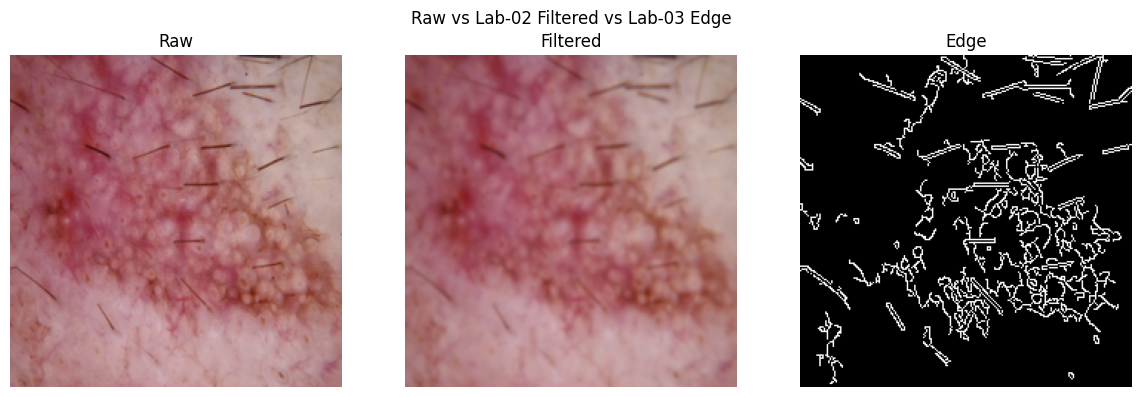

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, representation in zip(axes, REPRESENTATIONS):
    if representation == "Raw":
        im = sample
    elif representation == "Filtered":
        im = apply_lab2_filter(sample, LAB2_BEST_FILTER)
    else:
        edge = canny(sample, BEST_CANNY_LOW, BEST_CANNY_HIGH, BEST_CANNY_KERNEL)
        im = cv2.cvtColor(edge, cv2.COLOR_GRAY2RGB)

    ax.imshow(im)
    ax.set_title(representation)
    ax.axis("off")

plt.suptitle("Raw vs Lab-02 Filtered vs Lab-03 Edge")
plt.tight_layout()
plt.show()

## 10. CNN model used for fair Raw / Filtered / Edge comparison
Lab 03 requires classification comparison. We use the same transfer-learning backbone and the same training settings for all three representations.

In [14]:
def build_resnet50(num_classes):
    model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


class EarlyStopper:
    def __init__(self, patience=3, min_delta=1e-4):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = float("inf")
        self.counter = 0
        self.best_state = None

    def step(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            self.best_state = copy.deepcopy(model.state_dict())
            return False
        self.counter += 1
        return self.counter >= self.patience

    def restore(self, model):
        if self.best_state is not None:
            model.load_state_dict(self.best_state)


def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss, correct, n = 0.0, 0, 0

    with torch.set_grad_enabled(is_train):
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)

            if is_train:
                optimizer.zero_grad()

            out = model(x)
            loss = criterion(out, y)

            if is_train:
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
            n += x.size(0)

    return total_loss / n, correct / n


def train_cnn(train_loader, val_loader,
              feat_epochs=3, ft_epochs=10,
              lr_head=1e-3, lr_ft=1e-4):
    model = build_resnet50(NUM_CLASSES).to(DEVICE)
    criterion = nn.CrossEntropyLoss()

    history = {
        "train_loss": [], "val_loss": [],
        "train_acc": [], "val_acc": []
    }

    # Phase 1: train only final classification layer
    for p in model.parameters():
        p.requires_grad = False

    for p in model.fc.parameters():
        p.requires_grad = True

    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr_head
    )

    for _ in range(feat_epochs):
        tr_loss, tr_acc = run_epoch(
            model, train_loader, criterion, optimizer
        )
        va_loss, va_acc = run_epoch(
            model, val_loader, criterion
        )

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(va_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(va_acc)

    # Phase 2: fine-tune all layers
    for p in model.parameters():
        p.requires_grad = True

    optimizer = optim.Adam(model.parameters(), lr=lr_ft)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, factor=(0.1) ** 0.5, patience=2
    )
    stopper = EarlyStopper(patience=3)

    for _ in range(ft_epochs):
        tr_loss, tr_acc = run_epoch(
            model, train_loader, criterion, optimizer
        )
        va_loss, va_acc = run_epoch(
            model, val_loader, criterion
        )

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(va_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(va_acc)

        scheduler.step(va_loss)

        if stopper.step(va_loss, model):
            break

    stopper.restore(model)
    return model, history

## 11. CNN evaluation — Accuracy, Precision, Recall, F1, training time and inference time

In [15]:
@torch.no_grad()
def evaluate_cnn(model, loader):
    model.eval()

    all_preds = []
    all_labels = []

    start = time.time()

    for x, y in loader:
        x = x.to(DEVICE)
        out = model(x)
        preds = out.argmax(1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(y.numpy())

    total_time = time.time() - start
    labels = np.array(all_labels)
    preds = np.array(all_preds)

    metrics = {
        "Accuracy": accuracy_score(labels, preds),
        "Precision": precision_score(
            labels, preds, average="weighted", zero_division=0
        ),
        "Recall": recall_score(
            labels, preds, average="weighted", zero_division=0
        ),
        "F1-Score": f1_score(
            labels, preds, average="weighted", zero_division=0
        ),
    }

    inference_ms = (total_time / len(labels)) * 1000
    metrics["Inference Time (ms/image)"] = inference_ms

    cm = confusion_matrix(labels, preds, labels=list(range(NUM_CLASSES)))

    return metrics, cm, labels, preds


cnn_results = []
cnn_models = {}
cnn_confusions = {}
cnn_histories = {}

for representation in REPRESENTATIONS:
    print(f"\n===== CNN | {representation} =====")

    train_loader, val_loader, test_loader = build_dataloaders(representation)

    start_train = time.time()

    model, history = train_cnn(
        train_loader,
        val_loader,
        feat_epochs=3,
        ft_epochs=10,
        lr_head=1e-3,
        lr_ft=1e-4
    )

    training_time = time.time() - start_train

    metrics, cm, labels, preds = evaluate_cnn(model, test_loader)

    row = {
        "Model / Classifier": "ResNet50 CNN",
        "Representation": representation,
        **metrics,
        "Training Time (s)": training_time,
    }

    cnn_results.append(row)
    cnn_models[representation] = model
    cnn_confusions[representation] = cm
    cnn_histories[representation] = history

    print(row)

cnn_results_df = pd.DataFrame(cnn_results)
display(cnn_results_df)


===== CNN | Raw =====
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 139MB/s]


{'Model / Classifier': 'ResNet50 CNN', 'Representation': 'Raw', 'Accuracy': 0.7, 'Precision': 0.7440123296747616, 'Recall': 0.7, 'F1-Score': 0.6881269841269841, 'Inference Time (ms/image)': 13.381856679916382, 'Training Time (s)': 255.06415915489197}

===== CNN | Filtered =====
{'Model / Classifier': 'ResNet50 CNN', 'Representation': 'Filtered', 'Accuracy': 0.6, 'Precision': 0.6618181818181819, 'Recall': 0.6, 'F1-Score': 0.573821025994939, 'Inference Time (ms/image)': 11.609166860580444, 'Training Time (s)': 217.2073540687561}

===== CNN | Edge =====
{'Model / Classifier': 'ResNet50 CNN', 'Representation': 'Edge', 'Accuracy': 0.375, 'Precision': 0.3485964912280702, 'Recall': 0.375, 'F1-Score': 0.31380262249827473, 'Inference Time (ms/image)': 11.919403076171875, 'Training Time (s)': 309.6672611236572}


,Model / Classifier,Representation,Accuracy,Precision,Recall,F1-Score,Inference Time (ms/image),Training Time (s)
0,ResNet50 CNN,Raw,0.700,0.744012,0.700,0.688127,13.381857,255.064159
1,ResNet50 CNN,Filtered,0.600,0.661818,0.600,0.573821,11.609167,217.207354
2,ResNet50 CNN,Edge,0.375,0.348596,0.375,0.313803,11.919403,309.667261


## 12. CNN training curves

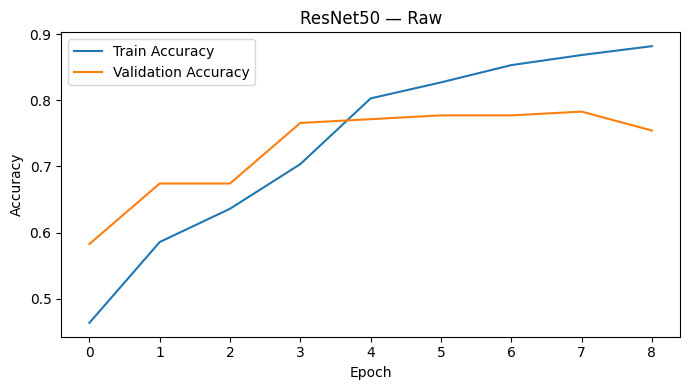

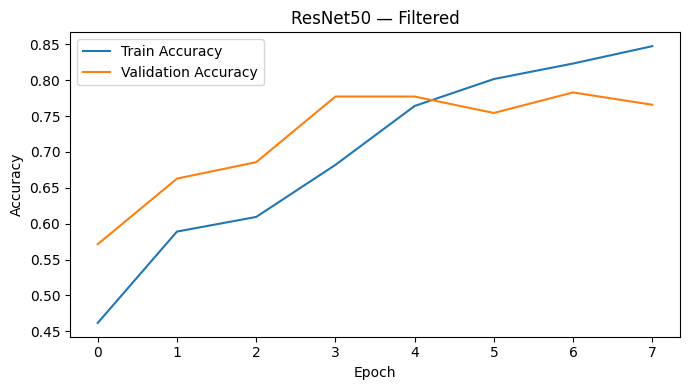

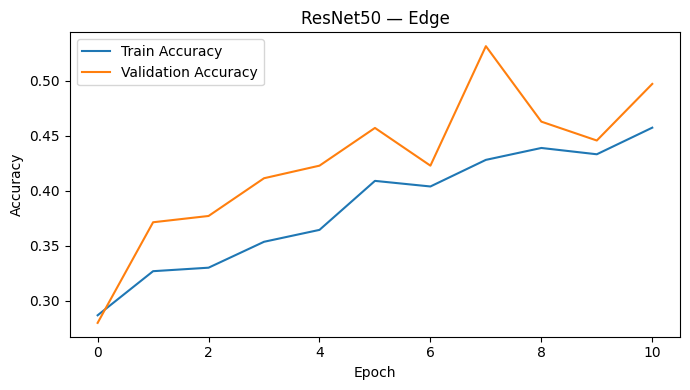

In [16]:
for representation, history in cnn_histories.items():
    plt.figure(figsize=(7, 4))
    plt.plot(history["train_acc"], label="Train Accuracy")
    plt.plot(history["val_acc"], label="Validation Accuracy")
    plt.title(f"ResNet50 — {representation}")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.show()

## 13. Confusion matrices for Raw, Filtered and Edge images

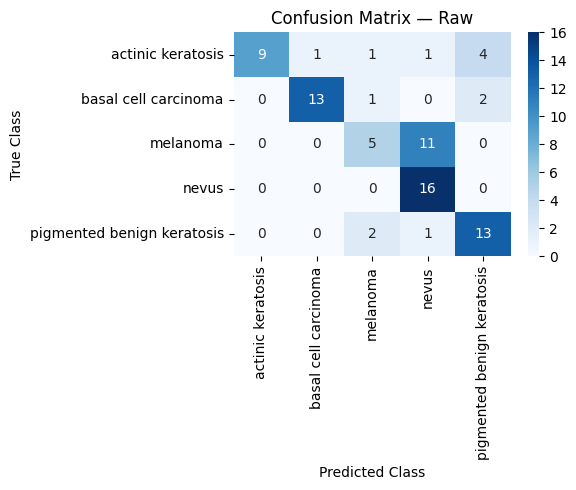

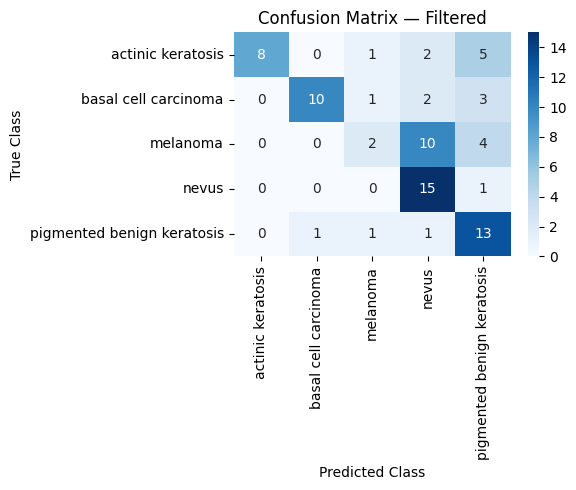

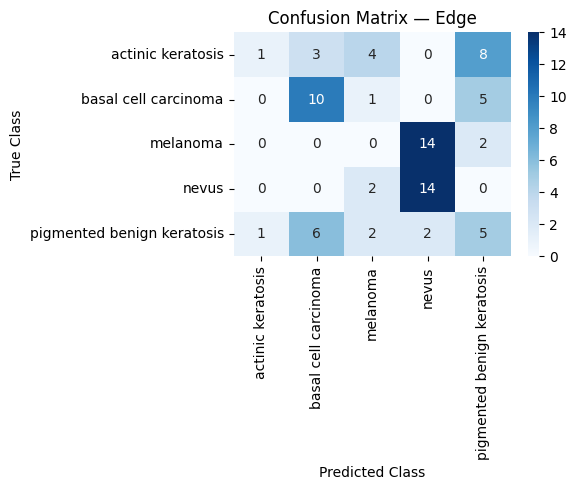

In [17]:
for representation in REPRESENTATIONS:
    cm = cnn_confusions[representation]

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=SELECTED_CLASSES,
        yticklabels=SELECTED_CLASSES
    )
    plt.title(f"Confusion Matrix — {representation}")
    plt.ylabel("True Class")
    plt.xlabel("Predicted Class")
    plt.tight_layout()
    plt.show()

## 14. Classical classifiers on CNN features
To satisfy the classification-comparison requirement, the same ResNet50 backbone is used as a feature extractor for SVM, Random Forest and KNN. The test set remains untouched until final evaluation.

In [18]:
@torch.no_grad()
def extract_features(model, loader):
    model.eval()

    feature_model = copy.deepcopy(model)
    feature_model.fc = nn.Identity()
    feature_model = feature_model.to(DEVICE)
    feature_model.eval()

    features = []
    labels = []

    for x, y in loader:
        x = x.to(DEVICE)
        f = feature_model(x)

        features.append(f.cpu().numpy())
        labels.append(y.numpy())

    return np.concatenate(features), np.concatenate(labels)


classical_results = []

classifiers = {
    "Linear SVM": SVC(kernel="linear"),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=SEED,
        n_jobs=-1
    ),
    "KNN": KNeighborsClassifier(n_neighbors=5),
}

for representation in REPRESENTATIONS:
    print(f"\n===== Classical classifiers | {representation} =====")

    train_loader, val_loader, test_loader = build_dataloaders(representation)

    model = cnn_models[representation]

    X_train, y_train = extract_features(model, train_loader)
    X_test, y_test = extract_features(model, test_loader)

    for clf_name, clf in classifiers.items():
        start = time.time()
        clf.fit(X_train, y_train)
        training_time = time.time() - start

        start_inf = time.time()
        preds = clf.predict(X_test)
        inference_time = (time.time() - start_inf) / len(y_test) * 1000

        classical_results.append({
            "Model / Classifier": clf_name,
            "Representation": representation,
            "Accuracy": accuracy_score(y_test, preds),
            "Precision": precision_score(
                y_test, preds, average="weighted", zero_division=0
            ),
            "Recall": recall_score(
                y_test, preds, average="weighted", zero_division=0
            ),
            "F1-Score": f1_score(
                y_test, preds, average="weighted", zero_division=0
            ),
            "Training Time (s)": training_time,
            "Inference Time (ms/image)": inference_time
        })

classical_results_df = pd.DataFrame(classical_results)
display(classical_results_df)


===== Classical classifiers | Raw =====

===== Classical classifiers | Filtered =====

===== Classical classifiers | Edge =====


,Model / Classifier,Representation,Accuracy,Precision,Recall,F1-Score,Training Time (s),Inference Time (ms/image)
0,Linear SVM,Raw,0.5875,0.731128,0.5875,0.535262,0.920091,0.574955
1,Random Forest,Raw,0.6000,0.672222,0.6000,0.522484,8.561306,0.676024
2,KNN,Raw,0.5625,0.623938,0.5625,0.538473,0.001900,1.515150
3,Linear SVM,Filtered,0.5250,0.562353,0.5250,0.496508,1.285313,0.723833
4,Random Forest,Filtered,0.6000,0.680203,0.6000,0.552910,7.591070,0.810254
5,KNN,Filtered,0.4875,0.477612,0.4875,0.447337,0.001961,0.829172
6,Linear SVM,Edge,0.3625,0.337807,0.3625,0.338980,3.088004,1.068106
7,Random Forest,Edge,0.3875,0.297802,0.3875,0.332049,8.963535,0.702178
8,KNN,Edge,0.3000,0.282979,0.3000,0.280838,0.002229,0.790870


## 15. Task 5 — Table 3: Cross-Lab Classification Performance

In [19]:
all_classification_results = pd.concat(
    [cnn_results_df, classical_results_df],
    ignore_index=True
)

display(
    all_classification_results.sort_values(
        ["Model / Classifier", "Representation"]
    ).reset_index(drop=True)
)

# Table 3 style view: one row per model, accuracy by representation.
table3_accuracy = all_classification_results.pivot_table(
    index="Model / Classifier",
    columns="Representation",
    values="Accuracy"
)

for col in ["Raw", "Filtered", "Edge"]:
    if col not in table3_accuracy.columns:
        table3_accuracy[col] = np.nan

table3_accuracy = table3_accuracy[["Raw", "Filtered", "Edge"]]
table3_accuracy.columns = [
    "Accuracy Raw (Lab 1)",
    "Accuracy Filtered (Lab 2)",
    "Accuracy Edge (Lab 3)"
]

display(table3_accuracy.round(4))

,Model / Classifier,Representation,Accuracy,Precision,Recall,F1-Score,Inference Time (ms/image),Training Time (s)
0,KNN,Edge,0.3000,0.282979,0.3000,0.280838,0.790870,0.002229
1,KNN,Filtered,0.4875,0.477612,0.4875,0.447337,0.829172,0.001961
2,KNN,Raw,0.5625,0.623938,0.5625,0.538473,1.515150,0.001900
3,Linear SVM,Edge,0.3625,0.337807,0.3625,0.338980,1.068106,3.088004
4,Linear SVM,Filtered,0.5250,0.562353,0.5250,0.496508,0.723833,1.285313
5,Linear SVM,Raw,0.5875,0.731128,0.5875,0.535262,0.574955,0.920091
6,Random Forest,Edge,0.3875,0.297802,0.3875,0.332049,0.702178,8.963535
7,Random Forest,Filtered,0.6000,0.680203,0.6000,0.552910,0.810254,7.591070
8,Random Forest,Raw,0.6000,0.672222,0.6000,0.522484,0.676024,8.561306
9,ResNet50 CNN,Edge,0.3750,0.348596,0.3750,0.313803,11.919403,309.667261


,Accuracy Raw (Lab 1),Accuracy Filtered (Lab 2),Accuracy Edge (Lab 3)
Model / Classifier,,,
KNN,0.5625,0.4875,0.3000
Linear SVM,0.5875,0.5250,0.3625
Random Forest,0.6000,0.6000,0.3875
ResNet50 CNN,0.7000,0.6000,0.3750


## 16. Best-performing model's visual comparison

Best test-set result for visualization:


,Value
Model / Classifier,ResNet50 CNN
Representation,Raw
Accuracy,0.7
Precision,0.744012
Recall,0.7
F1-Score,0.688127
Inference Time (ms/image),13.381857
Training Time (s),255.064159


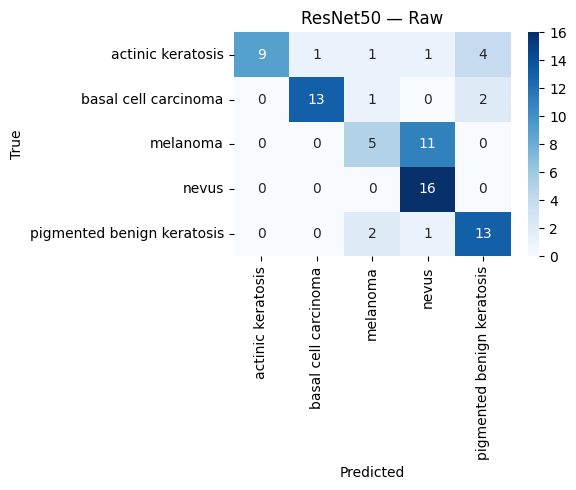

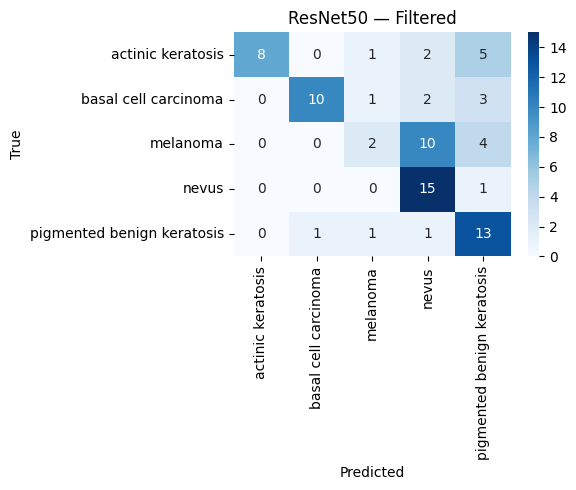

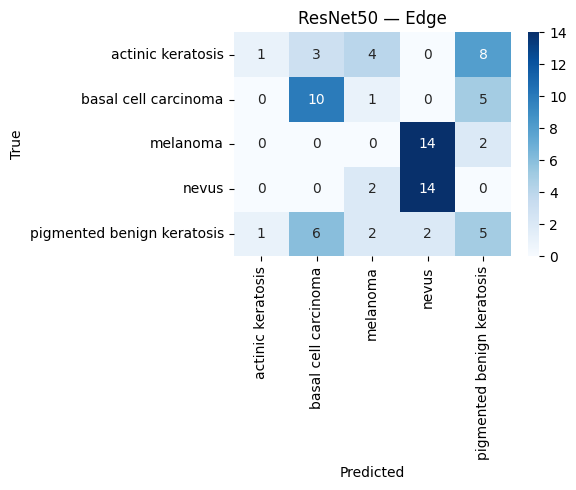

In [20]:
# Select the best model/representation using F1-score on the held-out test set.
# This is for visualization/reporting after evaluation, not for training decisions.
best_row = all_classification_results.loc[
    all_classification_results["F1-Score"].idxmax()
]

print("Best test-set result for visualization:")
display(best_row.to_frame("Value"))

# CNN confusion matrices are available for the three representations.
# For a direct Raw/Filtered/Edge comparison, use the CNN model because
# its architecture and training procedure are identical across all three.
for representation in REPRESENTATIONS:
    cm = cnn_confusions[representation]

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=SELECTED_CLASSES,
        yticklabels=SELECTED_CLASSES
    )
    plt.title(f"ResNet50 — {representation}")
    plt.ylabel("True")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()

## 17. Accuracy / Precision / Recall / F1 comparison

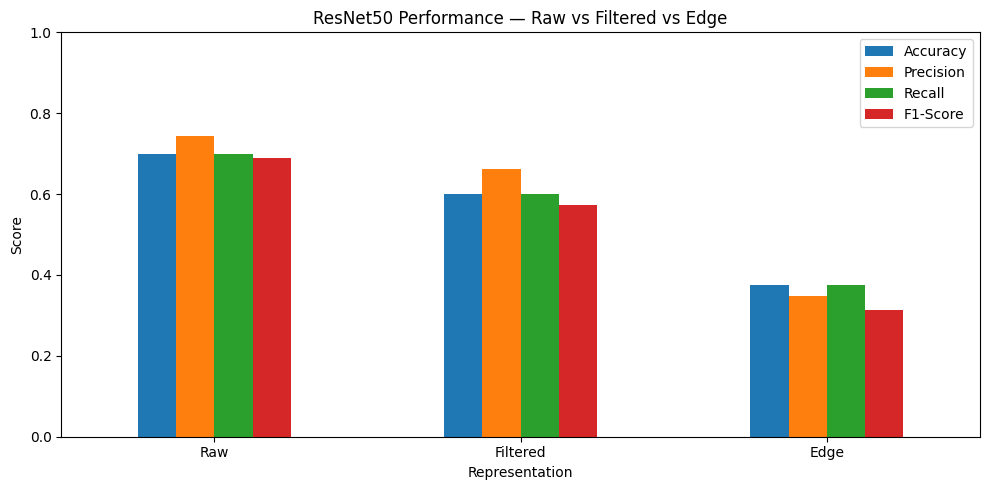

,Accuracy,Precision,Recall,F1-Score
Representation,,,,
Raw,0.700,0.7440,0.700,0.6881
Filtered,0.600,0.6618,0.600,0.5738
Edge,0.375,0.3486,0.375,0.3138


In [21]:
cnn_plot_df = cnn_results_df.set_index("Representation")[
    ["Accuracy", "Precision", "Recall", "F1-Score"]
]

ax = cnn_plot_df.plot(
    kind="bar",
    figsize=(10, 5)
)

ax.set_title("ResNet50 Performance — Raw vs Filtered vs Edge")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

display(cnn_plot_df.round(4))

## 18. Required observations for Task 3 and Task 2

In [22]:
# Objective Canny edge-pixel comparison
print("Canny edge-pixel counts:")
display(canny_df)

# Quantitative edge density can support the discussion, but visual quality
# (continuity, sharpness, false edges and broken edges) must be judged from figures.
canny_density = canny_df.copy()
canny_density["Edge Density (%)"] = (
    canny_density["Number of Detected Edges"] /
    (IMG_SIZE * IMG_SIZE) * 100
)

display(canny_density)

Canny edge-pixel counts:


,Configuration,Low Threshold,High Threshold,Kernel Size,Edge Quality,Number of Detected Edges,Observation
0,Canny-1,30,100,3x3,,9416,
1,Canny-2,50,150,3x3,,4399,
2,Canny-3,100,200,3x3,,1441,
3,Canny-4,50,150,5x5,,961,


,Configuration,Low Threshold,High Threshold,Kernel Size,Edge Quality,Number of Detected Edges,Observation,Edge Density (%)
0,Canny-1,30,100,3x3,,9416,,18.765944
1,Canny-2,50,150,3x3,,4399,,8.767140
2,Canny-3,100,200,3x3,,1441,,2.871891
3,Canny-4,50,150,5x5,,961,,1.915258


## 19. Export tables

In [23]:
os.makedirs("results", exist_ok=True)

table1.to_csv("results/lab03_table1_noise_edge_observations.csv", index=False)
canny_df.to_csv("results/lab03_table2_canny_analysis.csv", index=False)
all_classification_results.to_csv(
    "results/lab03_classification_results.csv",
    index=False
)
table3_accuracy.to_csv(
    "results/lab03_table3_cross_lab_accuracy.csv"
)

print("Saved:")
print(" - results/lab03_table1_noise_edge_observations.csv")
print(" - results/lab03_table2_canny_analysis.csv")
print(" - results/lab03_classification_results.csv")
print(" - results/lab03_table3_cross_lab_accuracy.csv")

Saved:
 - results/lab03_table1_noise_edge_observations.csv
 - results/lab03_table2_canny_analysis.csv
 - results/lab03_classification_results.csv
 - results/lab03_table3_cross_lab_accuracy.csv
